In [1]:
import pycea 
import numpy as np
import matplotlib.pyplot as plt
import json
import logging
from dataclasses import fields
import csv

logger = logging.getLogger(__name__)

In [2]:
def print_chart(data: pycea.CEAOutput, property: str, filename="output.png", output_folder="./output") -> None:
    valid_names = [f.name for f in fields(pycea.CEAResults)]
    if property not in valid_names:
        logger.warning(f"Invalid property. Valid propertues: {valid_names}, got {property!r}")
        raise ValueError(f"property must be one of {valid_names},  got {property!r}")

    fig, ax = plt.subplots()

    for i, P in enumerate(data.inputs.P):
        ax.plot(data.inputs.OF, getattr(data.results, property)[i, :], label=f"P = {(P*1e-5):.1f}")

    ax.set_xlabel("O/F ratio")
    ax.set_ylabel(f"{property}")
    ax.set_title(f"{data.inputs.fuel}/{data.inputs.ox} - {property} vs O/F ratio")
    ax.legend()

    fig.savefig(f"{output_folder}/{filename}")

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path

# Property -> axis label with units. Extend this to match your CEAResults fields.
PROPERTY_LABELS = {
    "Isp": r"Specific Impulse, $I_{sp}$ (s)",
    "cstar": r"Characteristic Velocity, $c^*$ (m/s)",
    "temp": r"Chamber Temperature, $T_c$ (K)",
    "k": r"Specific heat ratio $k$ (-)",
    "M": r"Molecular weight $M$ (g/mol)",

}

CHART_TITLES = {
    "Isp": r"Specific impulse:",
    "cstar": r"Characteristic velocity:",
    "temp": r"Adiabatic flame temperature:",
    "k": r"Specific heat ratio:",
    "M": r"Molecular weight:",
}


def set_paper_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 18,
        "legend.fontsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.5,
        "mathtext.fontset": "cm",
        "svg.fonttype": "none",   # keep text as text, not paths, in SVG
        "pdf.fonttype": 42,       # embed fonts properly in PDF (avoids Type 3 issues)
    })


def print_chart(data: pycea.CEAOutput, property: str, filename="output", output_folder="./output") -> None:
    valid_names = [f.name for f in fields(pycea.CEAResults)]
    if property not in valid_names:
        logger.warning(f"Invalid property. Valid properties: {valid_names}, got {property!r}")
        raise ValueError(f"property must be one of {valid_names}, got {property!r}")

    set_paper_style()

    # IAC papers are single-column (~16.5 cm text width), so a wider figure
    # reads well without needing to span two columns like AIAA/Elsevier.
    fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)

    linestyles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D"]
    colors = plt.cm.viridis([0.15, 0.55, 0.85])

    for i, P in enumerate(data.inputs.P):
        ax.plot(
            data.inputs.OF,
            getattr(data.results, property)[i, :],
            label=rf"$P_c$ = {(P*1e-5):.0f} bar",
            color=colors[i % len(colors)],
            linestyle=linestyles[i % len(linestyles)],
        )

    ax.set_xlabel("O/F ratio (-)")
    ax.set_ylabel(PROPERTY_LABELS.get(property, property))
    ax.set_title(f"{CHART_TITLES.get(property, property)} {data.inputs.fuel}/{data.inputs.ox}", loc="center")

    ax.grid(True, which="major", linestyle=":", linewidth=0.5, alpha=0.6)
    ax.legend(frameon=False, loc="best")
    ax.set_xlim(data.inputs.OF.min(), data.inputs.OF.max())

    Path(output_folder).mkdir(parents=True, exist_ok=True)

    # Save all three formats from one figure
    for ext in ("pdf", "svg", "png"):
        fig.savefig(f"{output_folder}/{filename}.{ext}", bbox_inches="tight",
                    dpi=600 if ext == "png" else None)

    plt.close(fig)

In [4]:
fuel_list = ["ABS", "PLA", "PETG", "CH4"]
ox_list = ["N2O", "O2", "H2O2:0.85, H2O:0.15"]
OF_list_N2O = np.linspace(1, 15, 100)
OF_list_H2O2 = np.linspace(1, 10, 100)
OF_list_O2 = np.linspace(0.5, 5, 100)
P_list = [10e5, 20e5, 30e5, 50e5] #np.linspace(10e5, 100e5, 2)


ambient_temp = 298 # K

results = []

max_isp = 0
f = ""
o = ""

for i, fuel in enumerate(fuel_list):
    for i2, ox in enumerate(ox_list):
        cea = pycea.CEA(fuel, ox, "filaments.yaml")
        if ox == "N2O":
            OF_list = OF_list_N2O
        elif ox == "O2":
            OF_list = OF_list_O2
        else:
            OF_list = OF_list_H2O2
        results.append(cea.run(OF_list, P_list, ambient_temp))
        if max_isp < np.max(results[-1].results.Isp):
            max_isp = np.max(results[-1].results.Isp)
            f = results[-1].inputs.fuel
            o = results[-1].inputs.ox

print(max_isp)
print(f)
print(o)







ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!


/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3524.502960598632 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver="auto")


ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!


/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3505.406434988143 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver="auto")
/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3509.4317706938555 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver="auto")
/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3511.7811219864916 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver="auto")
/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3512.7415689674904 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver="auto")
/home/seba/Python/pycea/src/pycea/cea.py:148: UserWarning: ChemEquil::equilibrate: Temperature (3512.539119765173 K) outside valid range of 300 K to 3500 K
  self._sim.equilibrate("HP", solver=

295.6600500365572
CH4
O2


In [5]:
SKIP = True

if not SKIP:
    property_list = ["Isp", "T", "k", "M", "cstar"]
    ylabel_list = [r"$I_{sp}$ [s]", r"$T^*$ [K]", r"k [-]", r"M [$g/{mol}$]", r"$c^*$ [$m/s$]"]
    for result in results:
        for i, property in enumerate(property_list):
            #print_chart(result, property, ylabel_list[i], filename=f"{property}_{result.inputs.fuel}_{result.inputs.ox}", output_folder="./output-claude2")
            print_chart(result, property, f"{property}_{result.inputs.fuel}_{result.inputs.ox}", "./output-claude/")

In [6]:
# Plot Isp for ABS/PETG/PLA for pressure of 30 bar on one plot


# extract P(OF) for each fuel/ox in question

fuel_list = ["ABS", "PETG", "PLA"]
ox_list2 = ["N2O", "O2", "H2O2:0.85, H2O:0.15"]
pressure = [10e5, 20e5, 30e5, 50e5]
output_folder = "./output"
property_list = ["Isp", "T", "M", "k"]

Isp_lists = []
T_lists = []
M_lists = []
k_lists = []
OF_lists = []

set_paper_style()

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D"]
colors = plt.cm.viridis([0.15, 0.55, 0.85])


for p in pressure:
    for ox in ox_list2:
        ox_name = ""
        if ":" in ox:
            for n in ox:
                if n == ":":
                    break
                else:
                    ox_name = f"{ox_name}{n}"
        else:
            ox_name = ox
        
        Isp_lists = []
        T_lists = []
        M_lists = []
        k_lists = []
        OF_lists = []
        for result in results:
            if result.inputs.fuel in fuel_list and result.inputs.ox == ox:
                index = result.inputs.P.index(p)
                OF_lists.append(result.inputs.OF)
                Isp_lists.append(result.results.Isp[index])
                T_lists.append(result.results.T[index])
                M_lists.append(result.results.M[index])
                k_lists.append(result.results.k[index])

        for property in property_list:
            fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)
            for i in np.arange(len(OF_lists)):
                property_values = []
                ylabel = ""
                title = ""
                if property == "Isp":
                    property_values = Isp_lists[i]
                    ylabel = r"Specific Impulse, $I_{sp}$ (s)"
                    title = f"{ox_name}, Isp at {int(p/1e5)} bar"
                if property == "T":
                    property_values = T_lists[i]
                    ylabel = r"Adiabatic flame temperature (K)"
                    title = f"{ox_name}, Flame temperature at {int(p/1e5)} bar"
                if property == "M":
                    property_values = M_lists[i]
                    ylabel = r"Molecular weight (g/mol)"
                    title = f"{ox_name}, Molecular weight at {int(p/1e5)} bar"
                if property == "k":
                    property_values = k_lists[i]
                    ylabel = r"Isentropic exponeny"
                    title = f"{ox_name}, Isentropic exponent at {int(p/1e5)} bar"
                
                ax.plot(OF_lists[i], property_values,
                        label=rf"{fuel_list[i]}",
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                    )

                ax.set_xlabel("O/F ratio (-)")
                ax.set_ylabel(ylabel)
                ax.set_title(title, loc="center")

                ax.grid(True, which="major", linestyle=":", linewidth=0.5, alpha=0.6)
                ax.legend(frameon=False, loc="best")
                ax.set_xlim(min(OF_lists[i]), max(OF_lists[i]))
            
            Path(f"{output_folder}/{property}").mkdir(parents=True, exist_ok=True)

            # Save all three formats from one figure
            for ext in ("pdf", "svg", "png"):
                fig_name = property.lower()
                for f in fuel_list:
                    fig_name = f"{fig_name}_{f}"
                fig_name = f"{fig_name}_{ox_name}"
                fig_name = f"{fig_name}_{int(p/1e5)}"
                fig.savefig(f"{output_folder}/{property}/{fig_name}.{ext}", bbox_inches="tight",
                            dpi=600 if ext == "png" else None)

            plt.close()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very l

In [7]:
# Plot Isp for ABS/PETG/PLA for pressure of 30 bar on one plot


# extract P(OF) for each fuel/ox in question

fuel_list2 = ["ABS", "PETG", "PLA"]
ox_list2 = ["N2O", "O2", "H2O2:0.85, H2O:0.15"]
pressure = [10e5, 20e5, 30e5, 50e5]
output_folder = "./output_OX"
property_list = ["Isp", "T", "M", "k"]

Isp_lists = []
T_lists = []
M_lists = []
k_lists = []
OF_lists = []

ox_list2_names = []
for ox in ox_list2:
    ox_name = ""
    if ":" in ox:
        for n in ox:
            if n == ":":
                break
            else:
                ox_name = f"{ox_name}{n}"
    else:
        ox_name = ox
    ox_list2_names.append(ox_name)

set_paper_style()

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D"]
colors = plt.cm.viridis([0.15, 0.55, 0.85])


for p in pressure:
    for f in fuel_list2:        
        Isp_lists = []
        T_lists = []
        M_lists = []
        k_lists = []
        OF_lists = []
        for result in results:
            if result.inputs.ox in ox_list2 and result.inputs.fuel == f:
                index = result.inputs.P.index(p)
                OF_lists.append(result.inputs.OF)
                Isp_lists.append(result.results.Isp[index])
                T_lists.append(result.results.T[index])
                M_lists.append(result.results.M[index])
                k_lists.append(result.results.k[index])

        for property in property_list:
            fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)
            for i in np.arange(len(OF_lists)):
                property_values = []
                ylabel = ""
                title = ""
                if property == "Isp":
                    property_values = Isp_lists[i]
                    ylabel = r"Specific Impulse, $I_{sp}$ (s)"
                    title = f"{f}, Isp at {int(p/1e5)} bar"
                if property == "T":
                    property_values = T_lists[i]
                    ylabel = r"Adiabatic flame temperature (K)"
                    title = f"{f}, Flame temperature at {int(p/1e5)} bar"
                if property == "M":
                    property_values = M_lists[i]
                    ylabel = r"Molecular weight (g/mol)"
                    title = f"{f}, Molecular weight at {int(p/1e5)} bar"
                if property == "k":
                    property_values = k_lists[i]
                    ylabel = r"Isentropic exponeny"
                    title = f"{f}, Isentropic exponent at {int(p/1e5)} bar"
                
                ax.plot(OF_lists[i], property_values,
                        label=rf"{ox_list2_names[i]}",
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                    )

                ax.set_xlabel("O/F ratio (-)")
                ax.set_ylabel(ylabel)
                ax.set_title(title, loc="center")

                ax.grid(True, which="major", linestyle=":", linewidth=0.5, alpha=0.6)
                ax.legend(frameon=False, loc="best")
                ax.set_xlim(min(OF_lists[i]), max(OF_lists[i]))
            
            Path(f"{output_folder}/{property}").mkdir(parents=True, exist_ok=True)

            # Save all three formats from one figure
            for ext in ("pdf", "svg", "png"):
                fig_name = property.lower()
                for ox in ox_list2_names:
                    fig_name = f"{fig_name}_{ox}"
                fig_name = f"{fig_name}_{f}"
                fig_name = f"{fig_name}_{int(p/1e5)}"
                fig.savefig(f"{output_folder}/{property}/{fig_name}.{ext}", bbox_inches="tight",
                            dpi=600 if ext == "png" else None)

            plt.close()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very l

In [8]:
""" single point data:
- Optimum Isp
- Optimum OF
- Molecular weight at optimum Isp
- k at optimum Isp
- T at optimum Isp
- Cf at optimum Isp
- c* at optimum Isp

all for each fuel-oxidizer combination and pressure, each pressure in separate .csv
for single fuel-oxidzer combination and all pressures, each fuel-ox combination in separate .csv
"""

fuel_list2 = ["ABS", "PETG", "PLA", "CH4"]
ox_list2 = ox_list
pressure = [10e5, 20e5, 30e5, 50e5]
output_folder = "./output_csv"
species_output_folder = "./output_csv/species"
exhaust_output_folder = "./output_csv/exhaust"
property_list = ["Isp", "T", "M", "k", "Cf", "cstar"]

mixture_list = []
Isp_list = []
T_list = []
M_list = []
k_list = []
Cf_list = []
cstar_list = []
OF_list = []

mixture = None
Isp = None
T = None
M = None
k = None
Cf = None
cstar = None
OF = None

ox_list2_names = []
for ox in ox_list2:
    ox_name = ""
    if ":" in ox:
        for n in ox:
            if n == ":":
                break
            else:
                ox_name = f"{ox_name}{n}"
    else:
        ox_name = ox
    ox_list2_names.append(ox_name)


for p in pressure:
    mixture_list = []
    Isp_list = []
    T_list = []
    M_list = []
    k_list = []
    Cf_list = []
    cstar_list = []
    OF_list = []

    for f in fuel_list2:
        for ox_index, ox in enumerate(ox_list2):
            print(f"-------- {f}/{ox} @ {int(p/1e5)} bar --------")
            mixture = f"{f}/{ox_list2_names[ox_index]}"
            Isp = None
            T = None
            M = None
            k = None
            Cf = None
            cstar = None
            OF = None
            for result in results:
                if result.inputs.ox == ox and result.inputs.fuel == f:
                    index = result.inputs.P.index(p)
                    Isp = max(result.results.Isp[index])
                    index2 = np.argmax(result.results.Isp[index])
                    T = result.results.T[index][index2]
                    M = result.results.M[index][index2]
                    k = result.results.k[index][index2]
                    Cf = result.results.Cf[index][index2]
                    cstar = result.results.cstar[index][index2]
                    OF = result.inputs.OF[index2]

                    mixture_list.append(mixture)
                    Isp_list.append(Isp)
                    T_list.append(T)
                    M_list.append(M)
                    k_list.append(k)
                    Cf_list.append(Cf)
                    cstar_list.append(cstar)
                    OF_list.append(OF)

                    rows = [[k, round(v,3)] for k, v in sorted(result.results.species[index][index2].items(), key=lambda x: x[1], reverse=True)]
                    Path(f"{species_output_folder}").mkdir(parents=True, exist_ok=True)
                    with open(f"{species_output_folder}/{f}_{ox_list2_names[ox_index]}_{int(p/1e5)}bar.csv", "w") as file:
                        writer = csv.writer(file)
                        writer.writerow(["specie", "Mass fraction"])
                        writer.writerows(rows)

                    cea = pycea.CEA(f, ox, "filaments.yaml")
                    output = cea.run([result.inputs.OF[index2]], [p]) 
                    cea._sim.SP = cea._sim.s, 101325
                    cea._sim.equilibrate("SP")
                    exhaust_species = cea._sim.mass_fraction_dict()

                    
                    rows = [[k, round(v,3)] for k, v in sorted(exhaust_species.items(), key=lambda x: x[1], reverse=True)]
                    Path(f"{exhaust_output_folder}").mkdir(parents=True, exist_ok=True)
                    with open(f"{exhaust_output_folder}/exhaust_{f}_{ox_list2_names[ox_index]}_{int(p/1e5)}bar.csv", "w") as file:
                        writer = csv.writer(file)
                        writer.writerow(["specie", "Mass fraction"])
                        writer.writerows(rows)

                    print(f"Isp: {Isp:.1f} sec")
                    print(f"T: {T:.0f} K")
                    print(f"M: {M:.1f} g/mol")
                    print(f"k: {k:.2f}")
                    print(f"Cf: {Cf:.2f}")
                    print(f"cstar: {cstar:.1f} m/s")
                    print(f"OF: {OF:.2f}")

    Path(f"{output_folder}").mkdir(parents=True, exist_ok=True)
    rows = [
        ["Propellant", "Isp", "OF", "cstar", "Cf", "T", "M", "k"],
        ["-", "sec", "-", "m/s", "-", "K", "g/mol", "-"]
    ]
    for i in np.arange(len(Isp_list)):
        rows.append([
            mixture_list[i],
            f"{Isp_list[i]:.0f}",
            f"{OF_list[i]:.1f}",
            f"{cstar_list[i]:.0f}",
            f"{Cf_list[i]:.2f}",
            f"{T_list[i]:.0f}",
            f"{M_list[i]:.1f}",
            f"{k_list[i]:.2f}"
        ])

    # columns = [[]]
    # for row in rows:
    #     for i, item in enumerate(row):
    #         if i+1 > len(columns):
    #             columns.append([])
    #         columns[i].append(item)

    with open(f"{output_folder}/{int(p/1e5)}bar.csv", mode="w") as file:
        writer = csv.writer(file)
        writer.writerows(rows)
        print(rows)
        print("csv written!")




-------- ABS/N2O @ 10 bar --------
Isp: 198.9 sec
T: 3226 K
M: 25.7 g/mol
k: 1.26
Cf: 1.26
cstar: 1547.3 m/s
OF: 4.82
-------- ABS/O2 @ 10 bar --------
Isp: 218.6 sec
T: 3397 K
M: 22.5 g/mol
k: 1.25
Cf: 1.26
cstar: 1700.1 m/s
OF: 1.64
-------- ABS/H2O2:0.85, H2O:0.15 @ 10 bar --------
Isp: 213.2 sec
T: 2886 K
M: 21.0 g/mol
k: 1.19
Cf: 1.27
cstar: 1651.1 m/s
OF: 4.91
-------- PETG/N2O @ 10 bar --------
Isp: 185.4 sec
T: 3070 K
M: 28.5 g/mol
k: 1.24
Cf: 1.26
cstar: 1441.1 m/s
OF: 4.25
-------- PETG/O2 @ 10 bar --------
Isp: 193.3 sec
T: 3232 K
M: 28.2 g/mol
k: 1.21
Cf: 1.26
cstar: 1499.3 m/s
OF: 1.45
-------- PETG/H2O2:0.85, H2O:0.15 @ 10 bar --------
Isp: 201.1 sec
T: 2776 K
M: 22.9 g/mol
k: 1.18
Cf: 1.27
cstar: 1556.7 m/s
OF: 4.27
-------- PLA/N2O @ 10 bar --------
Isp: 180.3 sec
T: 2914 K
M: 28.8 g/mol
k: 1.23
Cf: 1.26
cstar: 1400.4 m/s
OF: 3.97
-------- PLA/O2 @ 10 bar --------
Isp: 185.3 sec
T: 3029 K
M: 29.2 g/mol
k: 1.19
Cf: 1.27
cstar: 1435.3 m/s
OF: 1.36
-------- PLA/H2O2:0.85, 

In [9]:
output_folder = "./output/species"
fuel_list2 = ["ABS", "PETG", "PLA", "CH4"]
ox_list2 = ox_list
pressure = [10e5, 20e5, 30e5, 50e5]

for i, fuel in enumerate(fuel_list):
    for i2, ox in enumerate(ox_list):
        cea = pycea.CEA(fuel, ox, "filaments.yaml")
        if ox == "N2O":
            OF_list = OF_list_N2O
        elif ox == "O2":
            OF_list = OF_list_O2
        else:
            OF_list = OF_list_H2O2
        results.append(cea.run(OF_list, P_list, ambient_temp))
        if max_isp < np.max(results[-1].results.Isp):
            max_isp = np.max(results[-1].results.Isp)
            f = results[-1].inputs.fuel
            o = results[-1].inputs.ox

# for result in results:
#     if result.inputs.ox == "N2O" and result.inputs.fuel == "ABS":
#         cea = pycea.CEA("ABS", "N2O", "filaments.yaml")
#         index = results.inputs.P.index(30e5)
#         Isp = max(result.results.Isp[index])
#         index2 = np.argmax(result.results.Isp[index])
#         output = cea.run([result.inputs.OF[index2]], [30e5])
#         cea._sim.P = 101325
#         cea._sim.equilibrate("HP")
#         exhaust_species = cea._sim.mass_fraction_dict()


print(results[0].results.species)
rows = [[k, v] for k, v in sorted(results[0].results.species[0][0].items(), key=lambda x: x[1], reverse=True)]

Path(f"{output_folder}").mkdir(parents=True, exist_ok=True)
with open(f"{output_folder}/species.csv", "w+", ) as file:
    writer = csv.writer(file)
    writer.writerow(["Specie", "fraction"])
    writer.writerows(rows)

ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
ERROR: FAILURE its = 1000!
[[{'ABS': 1.816700872321831e-09, 'ABS(wet)': 1.4149342730457033e-08, 'C2H': 7.41576227665626e-13, 'C2H2': 0.14177236273537885, 'C2H3': 2.8783022825846566e-08, 'C2H4': 0.11399748565011787, 'C2H5': 3.543297177429315e-08, 'C2H6': 0.0006429226692070024, 'C3H7': 3.1856611708471955e-09, 'C3H8': 5.9834453054629996e-05, 'CH2CHO': 3.3570690893269457e-13, 'CH2CO': 3.6974192334804284e-06, 'CH2O': 8.705930874684849e-10, 'CH2OH': 6.3351606108237876e-18, 'CH3CHO': 8.587646510481844e-09, 'CH3O': 8.033515627765433e-20, 'CH3OH': 1.258342418442175e-13, 'CH4': 0.01859322537937311, 'CN': 1.949941515595844e-12, 'CO': 0.29773859160247634, 'CO2': 1.04350456501763e-06, 'H': 2.6263479737276157e-12, 'H2': 3.669328052224

In [10]:
import cantera as ct
import Rocketry_formulas as rf
from scipy.constants import R

print(ct.__version__)

p_ch = 40e5
p_e = 101325

gas = ct.Solution("filaments.yaml")
gas.Y = "O2:3, CH4:1"
gas.TP = 300, p_ch
gas.equilibrate("HP")

k = gas.cp_mass/gas.cv_mass
M = gas.mean_molecular_weight
T = gas.T
Rs = R/M * 1000

Isp = rf.calculate_isp_ideal(k, Rs, T, p_ch, p_e)
cstar = rf.calculate_cstar_ideal(k, Rs, T)

print(f"k: {k}")
print(f"M: {M}")
print(f"T: {T}")
print(f"Isp: {Isp}")
print(f"cstar: {cstar}")


3.2.0
k: 1.2060277450373051
M: 20.073196506246635
T: 3490.366132947275
Isp: 286.4764899133769
cstar: 1850.683185618025


In [11]:
output_folder = "./output"
fig_name = "species"

mixtures_list = [
    "$\mathrm{ABS}$, $\mathrm{N_2O}$",
    "$\mathrm{PLA}$, $\mathrm{N_2O}$",
    "$\mathrm{PETG}$, $\mathrm{N_2O}$",
    "$\mathrm{ABS}$, $\mathrm{O_2}$",
    "$\mathrm{PLA}$, $\mathrm{O_2}$",
    "$\mathrm{PETG}$, $\mathrm{O_2}$",
    "$\mathrm{ABS}$, $\mathrm{H_2O_2}$",
    "$\mathrm{PLA}$, $\mathrm{H_2O_2}$",
    "$\mathrm{PETG}$, $\mathrm{H_2O_2}$"
]
species = {
    "CO2": [0.105, 0.275, 0.231, 0.172, 0.543, 0.432, 0.274, 0.368, 0.359],
    "CO": [0.267, 0.097, 0.158, 0.639, 0.217, 0.383, 0.151, 0.042, 0.073],
    "H2O": [0.065, 0.09, 0.061, 0.126, 0.183, 0.126, 0.535, 0.56, 0.532],
    #"OH": [0.009, 0.008, 0.009, 0.023, 0.019, 0.023, 0.017, 0.011, 0.015],
    "N2": [0.537, 0.505, 0.514, 0.016, 0 .002, 0.002, 0.007, 0.001, 0.001],
    "Others": [0.025, 0.033, 0.036, 0.047, 0.055, 0.057, 0.033, 0.029, 0.035]
}

colors = ['#e92741', '#f7942c', '#125b92', '#6ccad4', '#0f0f0f'] # , '#8dc53c'

fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)


bottom = [0] * len(mixtures_list)
i = 0

for component, values in species.items():
    color = [colors[i] for c in colors]
    ax.bar(mixtures_list, values, bottom = bottom, label=component, color = color)
    bottom = [b + v for b, v in zip(bottom, values)]
    i = i+1
    

ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='center')
fig.legend(loc="outside right center")
ax.set_ylabel("Mass fraction")


Path(f"{output_folder}").mkdir(parents=True, exist_ok=True)

# Save all three formats from one figure
for ext in ("pdf", "svg", "png"):
    fig.savefig(f"{output_folder}/{fig_name}.{ext}", bbox_inches="tight",
                dpi=600 if ext == "png" else None)

plt.close()


<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2687276759.py, line 20)

/tmp/ipykernel_2455/2120311185.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


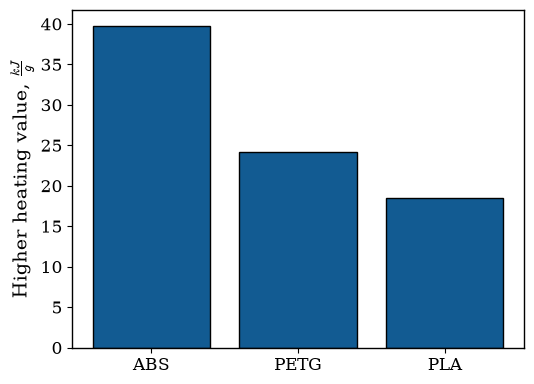

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [ ]:
output_folder = "./output/raw"
fig_name = "HHV"
colors = ['#e92741', '#f7942c', '#125b92', '#6ccad4', '#0f0f0f'] # , '#8dc53c'

# Your data: one list of values per "series" (the two bars in each group)
HHV_AR = [39.735, 24.190, 18.465]     # first bar in each group
HHV_d = [39.908, 24.295, 18.545]     # second bar in each group

labels = ["ABS", "PETG", "PLA"]

x = np.arange(len(labels))   # [0, 1, 2] -- base position for each group
width = 0.2                  # width of each bar

fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)

# Offset each series so bars sit side by side instead of overlapping
# bar1 = ax.bar(x - width/2, HHV_AR, width, label='As received')
ax.bar(labels, HHV_AR, color='#125b92', edgecolor='black', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)
#ax.set_title("Bomb calorimetry results")
ax.set_ylabel(r"Higher heating value, $\frac{kJ}{g}$")

plt.tight_layout()
plt.show()


Path(f"{output_folder}").mkdir(parents=True, exist_ok=True)

# Save all three formats from one figure
for ext in ("pdf", "svg", "png"):
    fig.savefig(f"{output_folder}/{fig_name}.{ext}", bbox_inches="tight",
                dpi=600 if ext == "png" else None)

plt.close()

In [ ]:
output_folder = "./output/raw"
fig_name = "CHNS"
colors = ['#e92741', '#f7942c', '#125b92', '#6ccad4', '#0f0f0f'] # , '#8dc53c'

# Your data: one list of values per "series" (the two bars in each group)
HHV_AR = [39.735, 24.190, 18.465]     # first bar in each group
HHV_d = [39.908, 24.295, 18.545]     # second bar in each group

labels = ["ABS", "PETG", "PLA"]

x = np.arange(len(labels))   # [0, 1, 2] -- base position for each group
width = 0.2                  # width of each bar

fig, ax = plt.subplots(figsize=(5.5, 4.0), constrained_layout=True)

# Offset each series so bars sit side by side instead of overlapping
# bar1 = ax.bar(x - width/2, HHV_AR, width, label='As received')
ax.bar(labels, HHV_AR, color='#125b92', edgecolor='black', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)
#ax.set_title("Bomb calorimetry results")
ax.set_ylabel(r"Higher heating value, $\frac{kJ}{g}$")

plt.tight_layout()
plt.show()


Path(f"{output_folder}").mkdir(parents=True, exist_ok=True)

# Save all three formats from one figure
for ext in ("pdf", "svg", "png"):
    fig.savefig(f"{output_folder}/{fig_name}.{ext}", bbox_inches="tight",
                dpi=600 if ext == "png" else None)

plt.close()